In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path 
import numpy as np


name = "DST_BIL54.csv"
df = pd.read_csv(name)

In [12]:
# "Total" angives i millioner 
df["total"] = df["total"]/(10**6)
# Object to datetime 
df["time"] = pd.to_datetime(df["time"])

In [13]:
# Creating a "year" column with decimal values for months
df["year"] = df["time"].dt.year + (df["time"].dt.month - 1) / 12

Vi koncenterer os herfra om variablerne "total" og "year":

* y:  total car registrations
* x:  datetime, year and month 

In [14]:
x = df["year"]
y = df["total"]

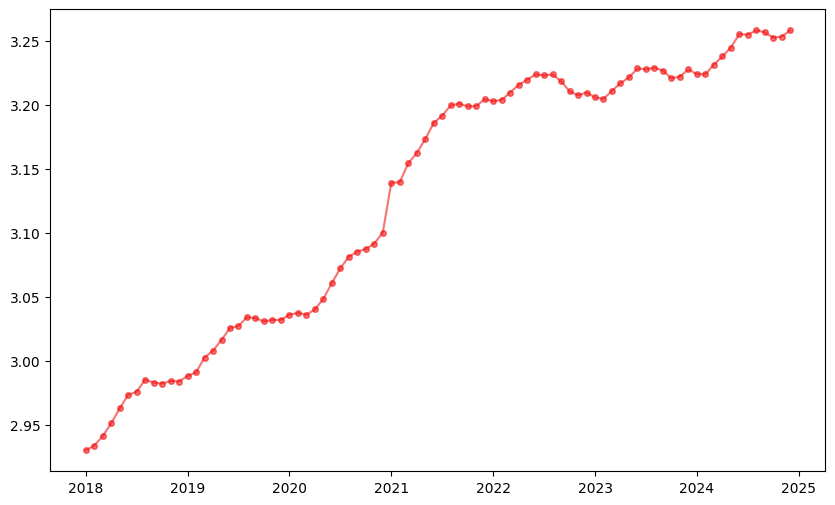

In [15]:
plt.figure(figsize=(10,6))
plt.plot(x, y, marker="o", linestyle="-", color="lightgrey", alpha = 0.4, markersize = 4)
plt.plot(x, y, marker="o", linestyle="-", color="red", alpha = 0.5, markersize = 4)


In [16]:
cut = "2024-01-01"
cut = pd.to_datetime(cut)


df_train = df[df["time"] < cut]
df_test  = df[df["time"] >= cut]


In [17]:
x_train = df_train["year"]
y_train = df_train["total"]
x_test = df_test["year"]
y_test = df_test["total"]

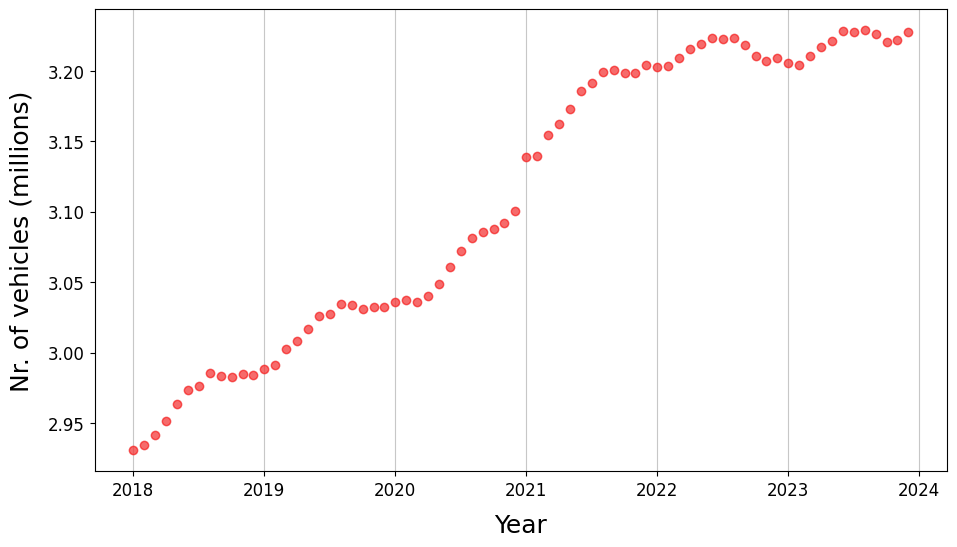

In [18]:
plt.figure(figsize=(11,6))
plt.plot(x_train, y_train, marker="o", linestyle="", label="Train", color = "lightgrey", alpha = 0.4)
plt.plot(x_train, y_train, marker="o", linestyle="", label="Train", color = "red", alpha = 0.55)
plt.grid(axis = "x", alpha = 0.7)
plt.xlabel("Year", fontsize = 18, labelpad=10)
plt.ylabel("Nr. of vehicles (millions)", fontsize = 18, labelpad=10)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.show()


GLM:

$Y_t = \theta_1 + \theta_2 \cdot x_t + \epsilon_t $

In [19]:
# Design matrix for training data
A = np.column_stack([np.ones(len(x_train)), x_train])

In [20]:
print("Determinant:",np.linalg.det(A.T @ A))
print("Rang: ", np.linalg.matrix_rank(A))

Determinant: 15549.000004242993
Rang:  2


In [21]:
c = np.linalg.solve(A.T@A, A.T@y_train)
print(c)

[-1.10355428e+02  5.61445562e-02]


In [22]:
c1 = np.linalg.lstsq(A, y_train, rcond=None)[0]   # mest stabilt
c2 = np.linalg.pinv(A) @ y_train                  # bruger Moore–Penrose pseudoinvers
c1, c2

(array([-1.10355428e+02,  5.61445562e-02]),
 array([-1.10355428e+02,  5.61445562e-02]))

In [23]:
y_pred = c[0] + c[1] * x_test
y_train_pred = c[0] + c[1] * x_train

In [24]:
y_pred.shape, y_test.shape

((12,), (12,))

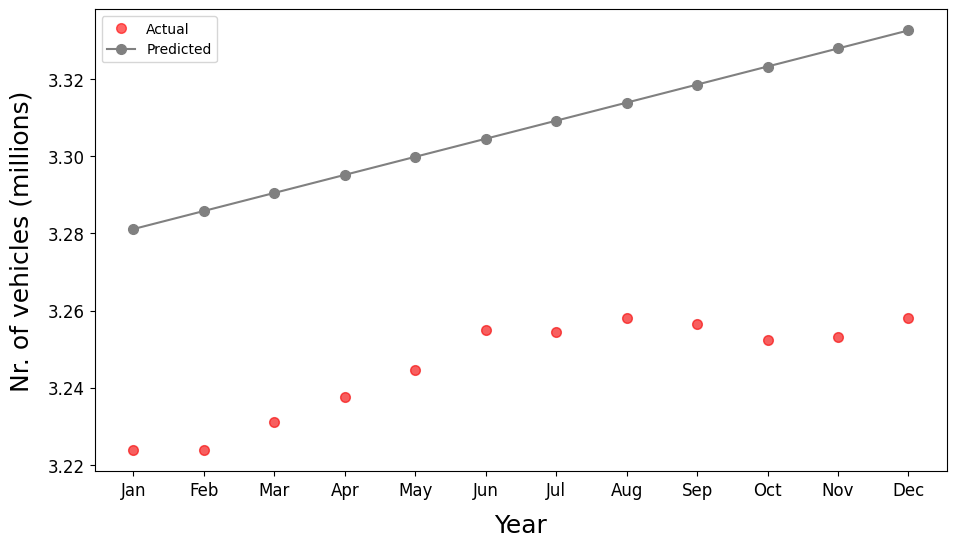

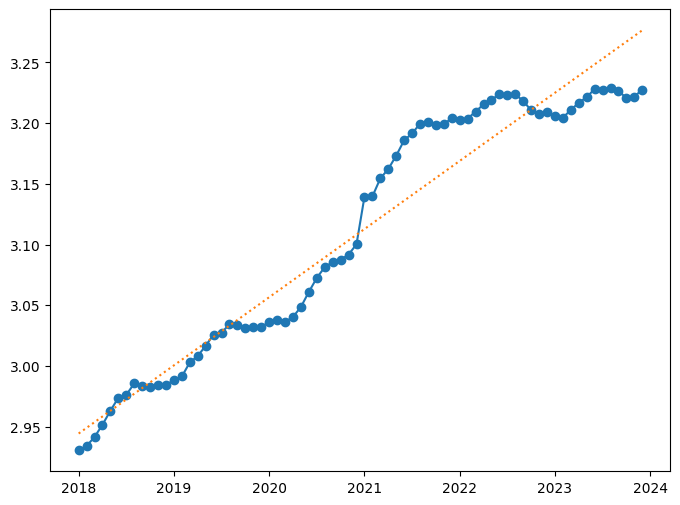

In [25]:
x_ind = np.arange(len(y_test)) # 0,1,2,...,11
plt.figure(figsize=(11,6))
plt.plot(x_ind, y_test, marker="o", linestyle="", color = "lightgrey", alpha = 0.4, markersize = 7)
plt.plot(x_ind, y_test, marker="o", linestyle="", color = "red", alpha = 0.6, label="Actual", markersize = 7)
plt.plot(x_ind, y_pred, label="Predicted", marker="o", linestyle="-", color = "grey", markersize = 7)
plt.xlabel("Year", fontsize = 18, labelpad=10)
plt.ylabel("Nr. of vehicles (millions)", fontsize = 18, labelpad=10)
plt.xticks(
    ticks = range(len(y_test)),
    labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
              "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    fontsize = 12
)

plt.yticks(fontsize = 12)

plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.plot(x_train, y_train, marker="o", linestyle="-", label="Train")
plt.plot(x_train, y_train_pred, label="Train Predicted", marker="", linestyle=":", markersize  = 7)

## Task 4

In [67]:
time_t = np.arange(0,N)

#4.1 find covariance variance matrix 
lambda_init = 0.9
N = len(df_train)
lambda_weights = lambda_init ** np.arange(N-1, -1, -1)
cov_var_matrix = np.diag(1/lambda_weights)

cov_var_matrix[60][60]

np.float64(3.186635545324934)

In [37]:
Sigma = np.diag(1 / lambda_weights)

Text(0, 0.5, 'weight (lambda)')

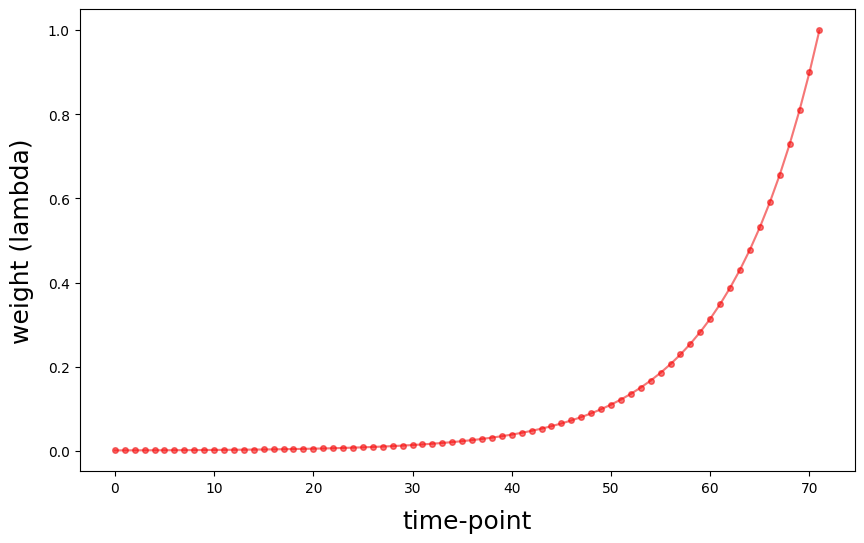

In [ ]:
#4.2 plot weights as a function of timepoints for 

plt.figure(figsize=(10,6))
plt.plot(time_t, lambda_weights, marker="o", linestyle="-", color="lightgrey", alpha = 0.4, markersize = 4)
plt.plot(time_t, lambda_weights, marker="o", linestyle="-", color="red", alpha = 0.5, markersize = 4)
plt.xlabel("time-point", fontsize = 18, labelpad=10)
plt.ylabel("weight (lambda)", fontsize = 18, labelpad=10)

In [51]:
# 4.3 sum weights (lambda) and OLS
print("sum of WLS weights", lambda_weights.sum())

print("\n sum of OLS weights", N)

sum of WLS weights 9.994924712139436

 sum of OLS weights 72


In [64]:
#estimate unknown params with weigts

theta = np.linalg.lstsq(A, y_train, rcond=None)[0]
print(theta)

[-1.10355428e+02  5.61445562e-02]
